In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time,math
import joblib
from datetime import datetime

# 设置支持中文的字体
plt.rcParams['font.family'] = 'SimHei'  # 可以根据系统情况替换为其他支持中文的字体

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 该目录用于保存最优模型参数
os.makedirs('model', exist_ok=True)

# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('scaler', exist_ok=True)

# 该目录用于保存可视化图片
os.makedirs('bp_images', exist_ok=True)

# 该目录用于保存日志文件
os.makedirs('logs', exist_ok=True)



os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = "OutputData/megered_涌水量水位.xlsx"
originData = pd.read_excel(file_path,index_col=0)
originData

,纬度,高程,日降雨量,涌水量,水位组_1_经度,水位组_1_纬度,水位组_1_高程,水位组_1_距离,水位组_1_水位,水位组_2_经度,...,水位组_25_经度,水位组_25_纬度,水位组_25_高程,水位组_25_距离,水位组_25_水位,水位组_26_经度,水位组_26_纬度,水位组_26_高程,水位组_26_距离,水位组_26_水位
经度,,,,,,,,,,,,,,,,,,,,,
400093.254,3044617.466,340,1.747,201.500,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,3.160,201.125,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,0.857,200.750,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,1.712,200.375,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,1.942,200.000,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401223.552,3044155.756,670,10.717,17.600,3044699.547,401076.749,905.05,3738158.909,853.677,3044705.773,...,304537741,40127407,670.61,3.063890e+08,679.340,3045730461,398843.511,941.53,3.045330e+09,909.628
401223.552,3044155.756,670,5.388,17.200,3044699.547,401076.749,905.05,3738158.909,853.595,3044705.773,...,304537741,40127407,670.61,3.063890e+08,679.040,3045730461,398843.511,941.53,3.045330e+09,909.774
401223.552,3044155.756,670,3.532,16.800,3044699.547,401076.749,905.05,3738158.909,853.582,3044705.773,...,304537741,40127407,670.61,3.063890e+08,678.840,3045730461,398843.511,941.53,3.045330e+09,910.064


In [3]:
target = originData['涌水量']
data = originData.drop(['涌水量'],axis=1)

In [4]:
data

,纬度,高程,日降雨量,水位组_1_经度,水位组_1_纬度,水位组_1_高程,水位组_1_距离,水位组_1_水位,水位组_2_经度,水位组_2_纬度,...,水位组_25_经度,水位组_25_纬度,水位组_25_高程,水位组_25_距离,水位组_25_水位,水位组_26_经度,水位组_26_纬度,水位组_26_高程,水位组_26_距离,水位组_26_水位
经度,,,,,,,,,,,,,,,,,,,,,
400093.254,3044617.466,340,1.747,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,400634.262,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,3.160,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,400634.262,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,0.857,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,400634.262,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,1.712,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,400634.262,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
400093.254,3044617.466,340,1.942,3044699.547,401076.749,905.05,3739284.729,856.408,3044705.773,400634.262,...,304537741,40127407,670.61,3.063900e+08,690.899,3045730461,398843.511,941.53,3.045332e+09,910.318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401223.552,3044155.756,670,10.717,3044699.547,401076.749,905.05,3738158.909,853.677,3044705.773,400634.262,...,304537741,40127407,670.61,3.063890e+08,679.340,3045730461,398843.511,941.53,3.045330e+09,909.628
401223.552,3044155.756,670,5.388,3044699.547,401076.749,905.05,3738158.909,853.595,3044705.773,400634.262,...,304537741,40127407,670.61,3.063890e+08,679.040,3045730461,398843.511,941.53,3.045330e+09,909.774
401223.552,3044155.756,670,3.532,3044699.547,401076.749,905.05,3738158.909,853.582,3044705.773,400634.262,...,304537741,40127407,670.61,3.063890e+08,678.840,3045730461,398843.511,941.53,3.045330e+09,910.064


In [5]:
type(data)

pandas.core.frame.DataFrame

In [6]:
type(target)

pandas.core.series.Series

# 1. 加载数据集

In [8]:
X = data.astype(np.float32)  # 特征
y = target.astype(np.float32).values.reshape(-1, 1)  # 目标值，转换为 NumPy 数组并重塑

In [9]:
X

,纬度,高程,日降雨量,水位组_1_经度,水位组_1_纬度,水位组_1_高程,水位组_1_距离,水位组_1_水位,水位组_2_经度,水位组_2_纬度,...,水位组_25_经度,水位组_25_纬度,水位组_25_高程,水位组_25_距离,水位组_25_水位,水位组_26_经度,水位组_26_纬度,水位组_26_高程,水位组_26_距离,水位组_26_水位
经度,,,,,,,,,,,,,,,,,,,,,
400093.254,3044617.50,340.0,1.747,3044699.5,401076.75,905.049988,3739284.75,856.408020,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306390016.0,690.898987,3.045731e+09,398843.5,941.530029,3.045331e+09,910.317993
400093.254,3044617.50,340.0,3.160,3044699.5,401076.75,905.049988,3739284.75,856.408020,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306390016.0,690.898987,3.045731e+09,398843.5,941.530029,3.045331e+09,910.317993
400093.254,3044617.50,340.0,0.857,3044699.5,401076.75,905.049988,3739284.75,856.408020,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306390016.0,690.898987,3.045731e+09,398843.5,941.530029,3.045331e+09,910.317993
400093.254,3044617.50,340.0,1.712,3044699.5,401076.75,905.049988,3739284.75,856.408020,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306390016.0,690.898987,3.045731e+09,398843.5,941.530029,3.045331e+09,910.317993
400093.254,3044617.50,340.0,1.942,3044699.5,401076.75,905.049988,3739284.75,856.408020,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306390016.0,690.898987,3.045731e+09,398843.5,941.530029,3.045331e+09,910.317993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401223.552,3044155.75,670.0,10.717,3044699.5,401076.75,905.049988,3738159.00,853.677002,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306388960.0,679.340027,3.045731e+09,398843.5,941.530029,3.045330e+09,909.627991
401223.552,3044155.75,670.0,5.388,3044699.5,401076.75,905.049988,3738159.00,853.594971,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306388960.0,679.039978,3.045731e+09,398843.5,941.530029,3.045330e+09,909.773987
401223.552,3044155.75,670.0,3.532,3044699.5,401076.75,905.049988,3738159.00,853.581970,3044705.75,400634.25,...,304537728.0,40127408.0,670.609985,306388960.0,678.840027,3.045731e+09,398843.5,941.530029,3.045330e+09,910.064026


In [10]:
y

array([[201.5  ],
       [201.125],
       [200.75 ],
       ...,
       [ 16.8  ],
       [ 16.4  ],
       [ 16.   ]], dtype=float32)

# 2. 划分训练集和测试集

In [12]:
# 第一次划分：分离测试集（20%）
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# 第二次划分：从训练集中分离验证集（20%的剩余数据作为验证集）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.2,  
    random_state=42
)

print('X_train type :',type(X_train))
print('X_train shape :',X_train.shape)
print('y_train shape :',y_train.shape)
print('X_val shape :',X_val.shape)
print('y_val shape :',y_val.shape)
print('X_test shape :',X_test.shape)
print('y_test shape :',y_test.shape)

X_train type : <class 'pandas.core.frame.DataFrame'>
X_train shape : (2658, 133)
y_train shape : (2658, 1)
X_val shape : (665, 133)
y_val shape : (665, 1)
X_test shape : (831, 133)
y_test shape : (831, 1)


# 3. 数据标准化

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('X_train_scaled type :',type(X_train_scaled))

X_train_scaled type : <class 'numpy.ndarray'>


In [15]:
X_train_scaled

array([[ 1.7480302 , -1.1369276 , -0.6682872 , ...,  0.        ,
         1.1655453 , -0.6804839 ],
       [ 0.9248727 , -1.819495  , -0.10853683, ...,  0.        ,
         1.1655453 ,  2.0988204 ],
       [-1.0737076 ,  0.6832522 , -0.00587522, ...,  0.        ,
         0.6372337 ,  1.8034941 ],
       ...,
       [ 0.9248727 , -1.819495  , -0.52296096, ...,  0.        ,
         1.1655453 ,  0.49831158],
       [-0.86610985,  1.3658196 , -0.33385915, ...,  0.        ,
        -0.9477012 , -0.25483882],
       [-0.86610985,  1.3658196 , -0.4314099 , ...,  0.        ,
        -0.9477012 , -0.4624595 ]], dtype=float32)

# 4. 将数据转换为 PyTorch 张量

In [17]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print('X_train_tensor shape :',X_train_tensor.shape)
print('y_train_tensor shape :',y_train_tensor.shape)
print('X_val_tensor shape :',X_val_tensor.shape)
print('y_val_tensor shape :',y_val_tensor.shape)
print('X_test_tensor shape :',X_test_tensor.shape)
print('y_test_tensor shape :',y_test_tensor.shape)

X_train_tensor shape : torch.Size([2658, 133])
y_train_tensor shape : torch.Size([2658, 1])
X_val_tensor shape : torch.Size([665, 133])
y_val_tensor shape : torch.Size([665, 1])
X_test_tensor shape : torch.Size([831, 133])
y_test_tensor shape : torch.Size([831, 1])


# 日志记录器

In [19]:
# 简单的日志记录器，支持日志恢复功能
class Logger:
    def __init__(self, log_file_path):
        self.log_file = log_file_path

        # 创建日志目录（如果不存在）
        os.makedirs(os.path.dirname(log_file_path), exist_ok=True)

        # 清空日志文件内容或创建新文件
        try:
            with open(log_file_path, 'w', encoding='utf-8') as f:
                f.write(f"训练开始: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        except Exception as e:
            print(f"日志写入失败: {e}")

    def log(self, message):
        """记录日志到文件并打印到控制台"""
        print(message)  # 保持原有打印

        # 写入主日志文件
        with open(self.log_file, 'a', encoding='utf-8') as f:
            f.write(f"{message}\n")

# 5. 构建 BP 神经网络模型

In [21]:
class RegressionModel(nn.Module):
    def __init__(self, input_size):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # 输入层 -> 隐藏层 1
        self.fc2 = nn.Linear(128, 64)          # 隐藏层 1 -> 隐藏层 2
        self.fc3 = nn.Linear(64, 32)           # 隐藏层 2 -> 输出层
        self.fc4 = nn.Linear(32, 1) 
        self.relu = nn.ReLU()                 # 激活函数

    def forward(self, x):
        x = self.relu(self.fc1(x))  # 隐藏层 1
        x = self.relu(self.fc2(x))  # 隐藏层 2
        x = self.relu(self.fc3(x))  # 隐藏层 2
        x = self.fc4(x)             # 输出层
        return x

# 6.初始化模型，并准备开始训练

In [23]:
# 初始化模型
input_size = X_train.shape[1]
model = RegressionModel(input_size)

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

# 训练模型
num_epochs = 1000
hist = np.zeros(num_epochs)
best_val_loss = float('inf')  # 用于保存验证集上的最佳损失
best_train_loss = float('inf') #保存训练集上得最佳损失
val_hist = np.zeros(num_epochs)  # 记录测试损失

# 获取当前时间并格式化为 "年-月-日_时-分-秒" 格式
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

best_model_path = f'model/{current_time}best_model.pth'  # 最佳模型保存路径
best_scaler_path = f'scaler/{current_time}best_scaler.pkl' #模型的scaler保存路径

 # 创建唯一的日志文件名
log_file = f"logs/{current_time}training.log"
logger = Logger(log_file)

logger.log(f'最优模型参数保存路径：{best_model_path}')
logger.log(f'scaler参数保存路径：{best_model_path}')

# 保存标准化参数
joblib.dump(scaler, best_scaler_path)

start_time = time.time()


for epoch in range(num_epochs):
    logger.log(f"-------------------第{epoch}次训练----------------------")
    # 训练模式
    model.train()
    # 前向传播
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    y_train_1 = y_train_tensor.detach().numpy();
    y_train_pred = outputs.detach().numpy();
    
    train_loss = math.sqrt(mean_squared_error(y_train_1[:, 0], y_train_pred[:, 0]))

    logger.log(f"Epoch epoch Train RMSE:{train_loss}")

    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 记录训练损失
    hist[epoch] = loss.item()

    # 验证模式
    model.eval()
    # 在验证集上评估
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        y_val_pred_1 = y_val_pred.detach().numpy()
        y_val_1 = y_val_tensor.detach().numpy()
        val_loss = math.sqrt(mean_squared_error(y_val_1[:, 0], y_val_pred_1[:, 0]))
        logger.log(f"Epoch epoch Val RMSE: {val_loss}")
        val_hist[epoch] = val_loss

        # 如果训练损失和测试损失都更好就修改
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            logger.log(f"Best model saved at epoch {epoch} with Val RMSE: {best_val_loss}")

training_time = time.time()-start_time
logger.log("Training time: {}".format(training_time))

最优模型参数保存路径：model/2025-06-29_01-22-53best_model.pth
scaler参数保存路径：model/2025-06-29_01-22-53best_model.pth
-------------------第0次训练----------------------
Epoch epoch Train RMSE:115.1323117927804
Epoch epoch Val RMSE: 113.63882358843081
Best model saved at epoch 0 with Val RMSE: 113.63882358843081
-------------------第1次训练----------------------
Epoch epoch Train RMSE:115.11535060673924
Epoch epoch Val RMSE: 113.62353890699761
Best model saved at epoch 1 with Val RMSE: 113.62353890699761
-------------------第2次训练----------------------
Epoch epoch Train RMSE:115.09979959664352
Epoch epoch Val RMSE: 113.60895702886943
Best model saved at epoch 2 with Val RMSE: 113.60895702886943
-------------------第3次训练----------------------
Epoch epoch Train RMSE:115.08494654764802
Epoch epoch Val RMSE: 113.59426581726078
Best model saved at epoch 3 with Val RMSE: 113.59426581726078
-------------------第4次训练----------------------
Epoch epoch Train RMSE:115.06998549795685
Epoch epoch Val RMSE: 113.57805943903735

# 7. 在测试集上进行评估

In [25]:
# 加载最佳模型
model.load_state_dict(torch.load(best_model_path,weights_only=True))  
model.eval()  # 将模型设置为评估模式

# 加载标准化格式scaler
scaler = joblib.load(best_scaler_path)

with torch.no_grad():
    y_train_pred_tensor = model(X_train_tensor)
    y_test_pred_tensor = model(X_test_tensor)

y_train_pred = y_train_pred_tensor.numpy()
y_test_pred = y_test_pred_tensor.numpy()

# 计算训练集和测试集的均方误差
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
logger.log('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
logger.log('Test Score: %.2f RMSE' % (testScore))

Train Score: 3.60 RMSE
Test Score: 5.11 RMSE


# 8.可视化数据

In [27]:
# 制作训练集上的可视化数据集
trainPlot = np.empty_like(y_train)
trainPlot[:,0] =np.nan 
trainPlot[:] = y_train

trainPredictPlot = np.empty_like(y_train_pred)
trainPredictPlot[:,0] =np.nan 
trainPredictPlot[:] = y_train_pred

logger.log(f'trainPlot shape : {trainPlot.shape}')
logger.log(f'trainPredictPlot shape : {trainPredictPlot.shape}')

predictions = np.append(trainPlot, trainPredictPlot, axis=1)
trainResult = pd.DataFrame(predictions)
trainResult.columns = ['originData','predictData'];

trainPlot shape : (2658, 1)
trainPredictPlot shape : (2658, 1)


In [28]:
# 制作测试集上的可视化数据集
testPlot = np.empty_like(y_test)
testPlot[:,0] =np.nan 
testPlot[:] = y_test

testPredictPlot = np.empty_like(y_test_pred)
testPredictPlot[:,0] =np.nan 
testPredictPlot[:] = y_test_pred

print('testPlot shape : ',testPlot.shape)
print('testPredictPlot shape : ',testPredictPlot.shape)
testPlot
predictions = np.append(testPlot, testPredictPlot, axis=1)
testResult = pd.DataFrame(predictions)
testResult.columns = ['originData','predictData'];

testPlot shape :  (831, 1)
testPredictPlot shape :  (831, 1)


In [29]:
trainResult

,originData,predictData
0,34.570999,34.759624
1,248.570999,250.636719
2,182.570999,178.448944
3,17.780001,21.074152
4,111.429001,115.029510
...,...,...
2653,25.000000,24.747793
2654,25.000000,28.586231
2655,328.571014,330.726135
2656,15.330000,13.564066


In [30]:
testResult

,originData,predictData
0,20.000000,19.386724
1,171.429001,170.027649
2,25.000000,25.219522
3,175.000000,172.556641
4,20.000000,18.882627
...,...,...
826,25.000000,24.308111
827,163.570999,162.775009
828,48.000000,48.774979
829,60.000000,57.721107


# 9.将集合好的数据进行可视化

In [32]:
trainResult.columns = [0,1];
# 将集合好的trainResult画图可视化
fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=trainResult.index, y=trainResult[0],
                    mode='lines',
                    name='Train Origin')))
fig.add_trace(go.Scatter(x=trainResult.index, y=trainResult[1],
                    mode='lines',
                    name='Train prediction'))
fig.update_layout(
        title={
        'text': 'Visualization on the training set',  # 替换为您的标题文本
        'x': 0.5,  # 标题水平居中
        'xanchor': 'center',
        'y': 0.9,  # 标题在图表的顶部
        'yanchor': 'top',
        'font': {
            'family': "Rockwell",
            'size': 20,
            'color': 'white'
        }
    },
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text="Value",
        title_font=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

In [33]:
# 将集合好的testResult画图可视化
testResult.columns = [0,1];
fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=testResult.index, y=testResult[0],
                    mode='lines',
                    name='Test Origin')))
fig.add_trace(go.Scatter(x=testResult.index, y=testResult[1],
                    mode='lines',
                    name='Test prediction'))
fig.update_layout(
        title={
        'text': 'Visualization on the Test set',  # 替换为您的标题文本
        'x': 0.5,  # 标题水平居中
        'xanchor': 'center',
        'y': 0.9,  # 标题在图表的顶部
        'yanchor': 'top',
        'font': {
            'family': "Rockwell",
            'size': 20,
            'color': 'white'
        }
    },
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text="Value",
        title_font=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

# 画一部分数据的可视化，方便查看

In [35]:
trainResult_part = trainResult.iloc[300:500];

In [36]:
testResult_part = testResult.iloc[300:500];

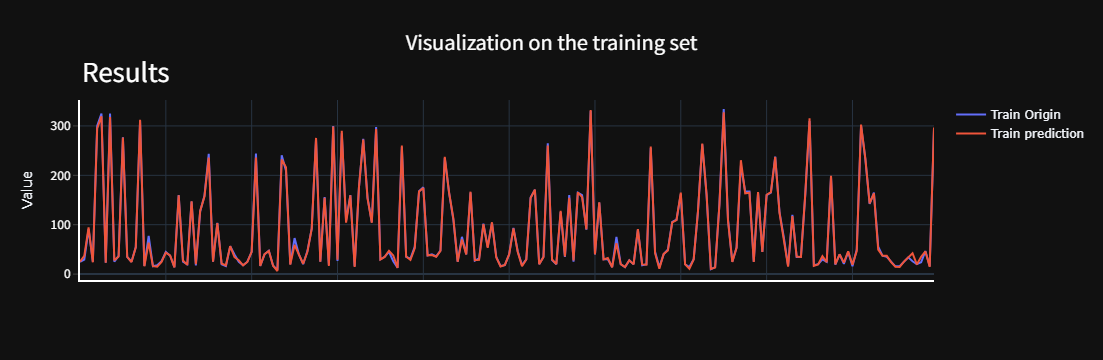

In [37]:
# 将集合好的trainResult画图可视化
fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=trainResult_part.index, y=trainResult_part[0],
                    mode='lines',
                    name='Train Origin')))
fig.add_trace(go.Scatter(x=trainResult_part.index, y=trainResult_part[1],
                    mode='lines',
                    name='Train prediction'))
fig.update_layout(
        title={
        'text': 'Visualization on the training set',  # 替换为您的标题文本
        'x': 0.5,  # 标题水平居中
        'xanchor': 'center',
        'y': 0.9,  # 标题在图表的顶部
        'yanchor': 'top',
        'font': {
            'family': "Rockwell",
            'size': 20,
            'color': 'white'
        }
    },
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text="Value",
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

Retrying in 8.07 seconds due to HTTPConnectionPool(host='localhost', port=50491): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x00000264E546B350>: Failed to establish a new connection: [WinError 10061] 由于目标计算机积极拒绝，无法连接。'))...
./bp_images/2025-06-29_01-22-53真实值vs预测值.png保存成功


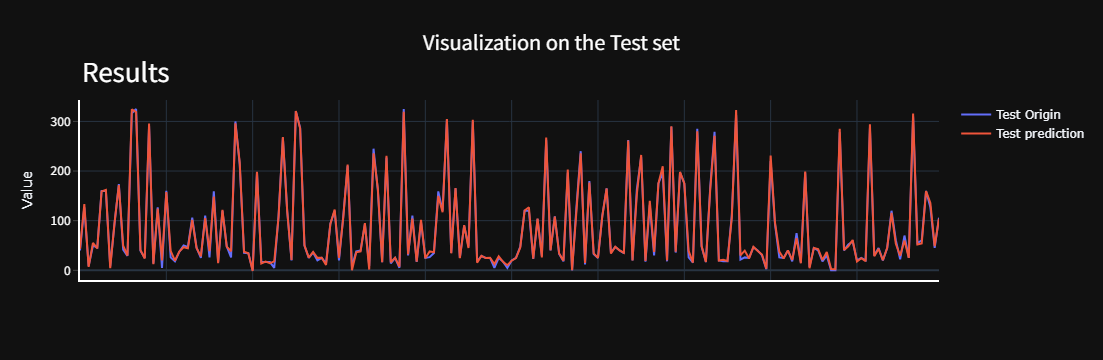

In [38]:
# 将集合好的testResult画图可视化
fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=testResult_part.index, y=testResult_part[0],
                    mode='lines',
                    name='Test Origin')))
fig.add_trace(go.Scatter(x=testResult_part.index, y=testResult_part[1],
                    mode='lines',
                    name='Test prediction'))
fig.update_layout(
        title={
        'text': 'Visualization on the Test set',  # 替换为您的标题文本
        'x': 0.5,  # 标题水平居中
        'xanchor': 'center',
        'y': 0.9,  # 标题在图表的顶部
        'yanchor': 'top',
        'font': {
            'family': "Rockwell",
            'size': 20,
            'color': 'white'
        }
    },
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=False,
        linecolor='white',
        linewidth=2
    ),
    yaxis=dict(
        title_text="Value",
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(
            family='Rockwell',
            size=12,
            color='white',
        ),
    ),
    showlegend=True,
    template = 'plotly_dark'

)



annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                              xanchor='left', yanchor='bottom',
                              text='Results',
                              font=dict(family='Rockwell',
                                        size=26,
                                        color='white'),
                              showarrow=False))
fig.update_layout(annotations=annotations)

# 保存可视化结果
image_path = f'./bp_images/{current_time}真实值vs预测值.png'
fig.write_image(image_path, width=1200, height=600, scale=2,engine='orca')
logger.log(f'{image_path}保存成功')
fig.show()

In [68]:
# 获取训练时的列名
expected_columns = scaler.get_feature_names_out()
expected_columns

array(['纬度', '高程', '日降雨量', '水位组_1_经度', '水位组_1_纬度', '水位组_1_高程', '水位组_1_距离',
       '水位组_1_水位', '水位组_2_经度', '水位组_2_纬度', '水位组_2_高程', '水位组_2_距离',
       '水位组_2_水位', '水位组_3_经度', '水位组_3_纬度', '水位组_3_高程', '水位组_3_距离',
       '水位组_3_水位', '水位组_4_经度', '水位组_4_纬度', '水位组_4_高程', '水位组_4_距离',
       '水位组_4_水位', '水位组_5_经度', '水位组_5_纬度', '水位组_5_高程', '水位组_5_距离',
       '水位组_5_水位', '水位组_6_经度', '水位组_6_纬度', '水位组_6_高程', '水位组_6_距离',
       '水位组_6_水位', '水位组_7_经度', '水位组_7_纬度', '水位组_7_高程', '水位组_7_距离',
       '水位组_7_水位', '水位组_8_经度', '水位组_8_纬度', '水位组_8_高程', '水位组_8_距离',
       '水位组_8_水位', '水位组_9_经度', '水位组_9_纬度', '水位组_9_高程', '水位组_9_距离',
       '水位组_9_水位', '水位组_10_经度', '水位组_10_纬度', '水位组_10_高程', '水位组_10_距离',
       '水位组_10_水位', '水位组_11_经度', '水位组_11_纬度', '水位组_11_高程', '水位组_11_距离',
       '水位组_11_水位', '水位组_12_经度', '水位组_12_纬度', '水位组_12_高程', '水位组_12_距离',
       '水位组_12_水位', '水位组_13_经度', '水位组_13_纬度', '水位组_13_高程', '水位组_13_距离',
       '水位组_13_水位', '水位组_14_经度', '水位组_14_纬度', '水位组_14_高程', '水位组_14_距离',
       '水位组_14_水位', '水位组_15_经度